## Naive Bayes Classifier - Rose

We trained a Naive Bayes classifier on the mushroom dataset to predict whether a mushroom is edible or poisonous.  


In [98]:
# Load the Processed Dataset
import pandas as pd

df = pd.read_csv("../Sources/data/processed_mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


In [99]:
# Separate Features and Target
X = df.drop("class", axis = 1) 
y = df["class"]

In [100]:
# Train/Test Split (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [101]:
# Train Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [102]:
# Make Predicitions
y_pred = model.predict(X_test)

In [103]:
# Model Evaluation (Accuracy, Precicion, Recall, and F-1 Score)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred):
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:", round(recall_score(y_true, y_pred), 3))
    print("F-1 Score:", round(f1_score(y_true, y_pred), 3))

print("Naive Bayes Results:\n")
evaluate(y_test, y_pred)


Naive Bayes Results:

Accuracy: 0.926
Precision: 0.919
Recall: 0.927
F-1 Score: 0.923


Overall, the Naive Bayes model performs well, showing it can reliably classify mushrooms based on the features provided.

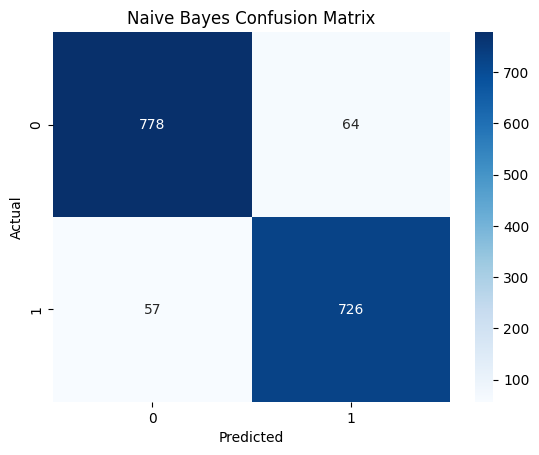

In [104]:
# Model Evaluation (Confusion Matrix)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

The confusion matrix for the Naive Bayes classifier shows that most edible and poisonous mushrooms were correctly classified, with a small number of misclassifications. Specifically, 778 edible mushrooms were correctly predicted as edible, while 64 were incorrectly classified as poisonous. Similarly, 726 poisonous mushrooms were correctly predicted, and 57 were incorrectly classified as edible.

The overall accuracy of the Naive Bayes model on the test dataset is 0.926, with strong precision, recall, and F1-score, indicating that the model reliably distinguishes between edible and poisonous mushrooms based on the features provided.

Compared to the decision tree models, Naive Bayes achieves slightly lower accuracy and has a few misclassifications, but it still performs well, demonstrating that probabilistic models can effectively classify mushrooms even without explicitly learning splits like a decision tree.

In [105]:
# Overfitting Check
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", round(train_acc, 3))
print("Test Accuracy:", round(test_acc, 3))

Training Accuracy: 0.92
Test Accuracy: 0.926
